# Finetuning RuBERT for mathematical problems classification

This project focuses on automated text classification of mathematical problems written in Russian into domain topics using deep learning and Transformer architectures.

Mathematical problem classification is challenging due to complex context, domain-specific terminology, and semantic overlap across mathematical branches

In [ ]:
!pip install bertviz kornia

### Imports

In [ ]:
import re
import random
import copy
import numpy as np
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm

from bertviz import head_view

from kornia.losses import FocalLoss


Reproducibility:

In [ ]:
SEED = 42
MAX_LENGTH = 256
BATCH_SIZE = 16

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device:

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


### Text preprocessing

Mathematical texts contain special symbols, Unicode operators, and formatting variations that require custom normalization, such as NFKC Normalization, Operator Standardization, Symbol Spacing,  Duplicate and Noise Removal

In [ ]:
def clean_and_normalize_math_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # NFKC normalization (converts special characters and fractions to standard Unicode)
    text = unicodedata.normalize('NFKC', text)

    # Standardize mathematical symbols and operators
    math_replacements = {
        '×': ' * ',
        '∙': ' * ',
        '·': ' * ',
        '÷': ' / ',
        '−': ' - ',
        '–': ' - ',
        '—': ' - ',
        '≤': ' <= ',
        '≥': ' >= ',
        '≠': ' != ',
        '≈': ' approx ',
        '∞': ' infty ',
        '°': ' deg ',
    }
    for char, repl in math_replacements.items():
        text = text.replace(char, repl)

    # Add spaces around mathematical operators for proper RuBERT tokenization
    text = re.sub(r'([=+\-*/^<>:])', r' \1 ', text)

    # Collapse multiple whitespaces into a single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
def process_and_clean_dataset(
    df: pd.DataFrame,
    text_col: str = "text",
    label_col: str = "label",
    exclude_classes: list = None
) -> pd.DataFrame:
    # Basic cleaning and dropping missing values
    df_cleaned = df.dropna(subset=[text_col, label_col]).copy()
    df_cleaned[text_col] = df_cleaned[text_col].astype(str)
    df_cleaned[text_col] = df_cleaned[text_col].apply(clean_and_normalize_math_text)
    df_cleaned = df_cleaned[df_cleaned[text_col].str.len() > 0]

    # Filter out excluded classes early
    if exclude_classes:
        df_cleaned = df_cleaned[~df_cleaned[label_col].isin(exclude_classes)]

    # Calculate local frequencies (for majority voting) and global frequencies (for tie-breaking)
    df_cleaned['pair_count'] = df_cleaned.groupby([text_col, label_col])[label_col].transform('count')
    df_cleaned['global_count'] = df_cleaned[label_col].map(df_cleaned[label_col].value_counts())

    # Sort by local label vote count, global class frequency
    df_final = df_cleaned.sort_values(
        by=['pair_count', 'global_count'],
        ascending=[False, False]
    )

    # Keep the highest-ranked label for each duplicate text
    df_final = df_final.drop_duplicates(subset=[text_col], keep='first')

    # Cleanup temporary columns
    df_final = df_final.drop(columns=['pair_count', 'global_count'])

    return df_final.reset_index(drop=True)

In [ ]:
# Load raw dataset
df_raw = pd.read_excel("Data/Data_Problems_Transforms.xlsx")
df_raw = df_raw.drop(df_raw.columns[0], axis=1).rename(
    columns={"Задача": "text", "Тема": "label"}
)

# Clean and resolve duplicate labels
exclude_list = ['Инвариант', 'Графы']  # Classes with minimal sample counts[cite: 1]
df_cleaned = process_and_clean_dataset(
    df=df_raw,
    text_col="text",
    label_col="label",
    exclude_classes=exclude_list
)

print(f"Cleaned dataset size: {len(df_cleaned)} tasks")
print("\nClass distribution:")
print(df_cleaned['label'].value_counts())

Cleaned dataset size: 4196 tasks

Class distribution:
label
Теория чисел     2387
Комбинаторика     815
Геометрия         366
Многочлен         360
Дирихле           268
Name: count, dtype: int64


#### Train/Val/Test split

In [ ]:
train_df, temp_df = train_test_split(
    df_cleaned, test_size=0.2, stratify=df_cleaned['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

#### Label Encoder

In [ ]:
label_encoder = LabelEncoder()

train_df['label_id'] = label_encoder.fit_transform(train_df['label'])
val_df['label_id'] = label_encoder.transform(val_df['label'])
test_df['label_id'] = label_encoder.transform(test_df['label'])

#### Dataset class

We implement a custom MathDataset class utilizing AutoTokenizer.from_pretrained("ai-forever/ruBert-large") with a maximum sequence length of 256. Data collators with dynamic padding are attached to PyTorch DataLoaders

In [ ]:
class MathDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts.iloc[idx],
            truncation=True,
            max_length=self.max_length
        )

        return {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels": torch.tensor(
                self.labels.iloc[idx],
                dtype=torch.long
            )
        }

#### Tokenizer RuBERT

In [ ]:
tokenizer_rubert = AutoTokenizer.from_pretrained("ai-forever/ruBert-large")

config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

#### DataLoaders

In [ ]:
train_dataset = MathDataset(
    train_df["text"],
    train_df["label_id"],
    tokenizer_rubert,
    max_length=MAX_LENGTH
)

val_dataset = MathDataset(
    val_df["text"],
    val_df["label_id"],
    tokenizer_rubert,
    max_length=MAX_LENGTH
)

test_dataset = MathDataset(
    test_df["text"],
    test_df["label_id"],
    tokenizer_rubert,
    max_length=MAX_LENGTH
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_rubert, padding=True)

In [ ]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
    pin_memory=torch.cuda.is_available()
)

print(
    "Train batches:",
    len(train_dataloader)
)

print(
    "Validation batches:",
    len(val_dataloader)
)

print(
    "Test batches:",
    len(test_dataloader)
)

Train batches: 210
Validation batches: 27
Test batches: 27


### Fix of the class imbalance problem

Due to significant class imbalance between majority classes and minority classes, standard Cross-Entropy loss can cause bias toward majority classes.To address this, we employ Focal Loss ($\gamma = 2.0, \alpha = 0.5$) from kornia.losses, which dynamically down-weights easy-to-classify examples and forces the model to focus on hard, ambiguous problems

In [ ]:
train_labels = train_df["label_id"].values
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)

soft_weights = [(total_samples / count) ** 0.4 for count in class_counts]
soft_weights = np.array(soft_weights) / np.mean(soft_weights)

criterion = FocalLoss(alpha=0.5, gamma=2.0, reduction='mean')

### Freeze layers function

We freeze the embeddings and lower encoder layers to preserve pre-trained general language representations, speed up training time, and prevent overfitting by forcing only the higher layers to adapt to the mathematical text classification task

In [ ]:
def freeze_layers(
    model,
    num_layers_to_freeze: int = 4
):
    # Freeze embeddings
    if hasattr(model.backbone, 'embeddings'):
        for param in model.backbone.embeddings.parameters():
            param.requires_grad = False

    # Freeze first N layers of the encoder
    if hasattr(model.backbone, 'encoder') and hasattr(model.backbone.encoder, 'layer'):
        for layer in model.backbone.encoder.layer[:num_layers_to_freeze]:
            for param in layer.parameters():
                param.requires_grad = False

    return model

### Transformer class

We define a custom PyTorch model TransformerClassificationModel wrapping ruBert-large

In [ ]:
class TransformerClassificationModel(nn.Module):
    def __init__(
        self,
        base_model_name: str,
        num_classes: int,
        dropout_rate: float = 0.2,
        num_layers_to_freeze: int = 4
    ):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(base_model_name, attn_implementation="eager")
        # Enabling attention saving in the model configuration
        self.backbone.config.output_attentions = True

        hidden_dim = self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )

        if num_layers_to_freeze > 0:
            freeze_layers(self, num_layers_to_freeze=num_layers_to_freeze)

    def forward(self, input_ids, attention_mask, return_attentions: bool = False):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=return_attentions,
            return_dict=True
        )
        hidden_states = outputs.last_hidden_state

        # Mean Pooling
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)

        mean_pooled = sum_embeddings / sum_mask
        logits = self.classifier(mean_pooled)

        result = {"logits": logits}
        if return_attentions:
            result["attentions"] = outputs.attentions

        return result

### Training, Evaluation and helper functions

In [ ]:
def print_trainable_parameters(model):

    trainable = 0
    total = 0

    for param in model.parameters():
        num_params = param.numel()
        total += num_params

        if param.requires_grad:
            trainable += num_params

    print(
        f"Trainable parameters: "
        f"{trainable:,}"
    )

    print(
        f"Total parameters: "
        f"{total:,}"
    )

    print(
        f"Trainable percentage: "
        f"{100 * trainable / total:.2f}%"
    )

#### Evaluation function

In [ ]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluation", leave=False):

            input_ids = (batch["input_ids"].to(device))
            attention_mask = (batch["attention_mask"].to(device))

            labels = (batch["labels"].to(device))
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]

            loss = criterion(logits, labels)
            total_loss += (loss.item())

            predictions = (logits.argmax(dim=1))
            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = (total_loss / len(dataloader))

    accuracy = accuracy_score(all_labels, all_predictions)

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    return (metrics, all_predictions, all_labels)

#### Transformer training function

In [ ]:
def train_transformer(
    model,
    criterion,
    train_loader,
    val_loader,
    device,
    backbone_lr=1e-5,
    head_lr=5e-5,
    num_epochs=8,
    weight_decay=0.01,
    warmup_ratio=0.10,
    max_grad_norm=1.0,
    patience=2,
    min_delta=0.001
):
    model = model.to(device)

    # Forming parameter groups (only for unfrozen scales)
    optimizer_groups = [
        {"params": [p for p in model.backbone.parameters() if p.requires_grad], "lr": backbone_lr},
        {"params": [p for p in model.classifier.parameters() if p.requires_grad], "lr": head_lr}
    ]
    optimizer_groups = [g for g in optimizer_groups if g["params"]]  # Cut off empty groups

    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=weight_decay)

    # Scheduler
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * warmup_ratio),
        num_training_steps=total_steps
    )

    best_val_f1 = -float("inf")
    best_state = None
    patience_counter = 0
    history = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs["logits"], labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation and metrics
        val_metrics, _, _ = evaluate_model(model, val_loader, criterion, device)
        current_f1 = val_metrics["macro_f1"]

        history.append({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": current_f1,
            "val_weighted_f1": val_metrics["weighted_f1"]
        })

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Macro-F1: {current_f1:.4f}"
        )

        # Early Stopping
        if current_f1 > (best_val_f1 + min_delta):
            best_val_f1 = current_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping on epoch {epoch + 1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

### RuBERT finetuning

In [ ]:
MODEL_NAME = "ai-forever/ruBert-large"
num_classes = len(label_encoder.classes_)

# Model init
model_rubert = TransformerClassificationModel(
    base_model_name=MODEL_NAME,
    num_classes=num_classes,
    dropout_rate=0.2,
    num_layers_to_freeze=8
)

untrained_model = copy.deepcopy(model_rubert)
untrained_model = untrained_model.to(device)

print_trainable_parameters(model_rubert)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.71GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ai-forever/ruBert-large
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Trainable parameters: 202,596,357
Total parameters: 426,915,845
Trainable percentage: 47.46%


In [ ]:
model_rubert, history_rubert = train_transformer(
    model=model_rubert,
    criterion=criterion,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    backbone_lr=1e-5,
    head_lr=5e-5,
    num_epochs=8,
    weight_decay=0.01,
    warmup_ratio=0.10,
    max_grad_norm=1.0,
    patience=2,
    min_delta=0.001
)

Epoch 1/8:   0%|          | 0/210 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 1/8 | Train Loss: 0.0511 | Val Loss: 0.0357 | Val Macro-F1: 0.6632


Epoch 2/8:   0%|          | 0/210 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 7/8 | Train Loss: 0.0017 | Val Loss: 0.0305 | Val Macro-F1: 0.7249


Epoch 8/8:   0%|          | 0/210 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 8/8 | Train Loss: 0.0011 | Val Loss: 0.0307 | Val Macro-F1: 0.7199
Early stopping on epoch 8.


#### Training Curves

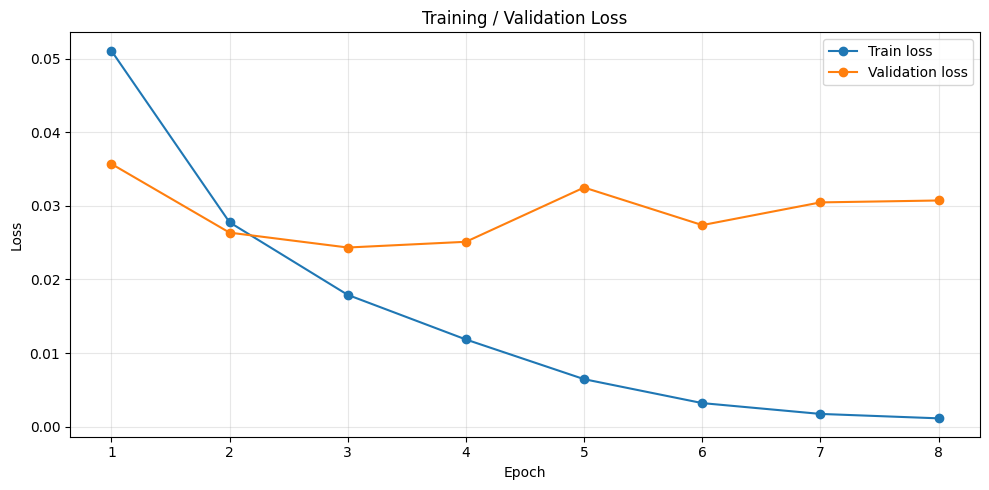

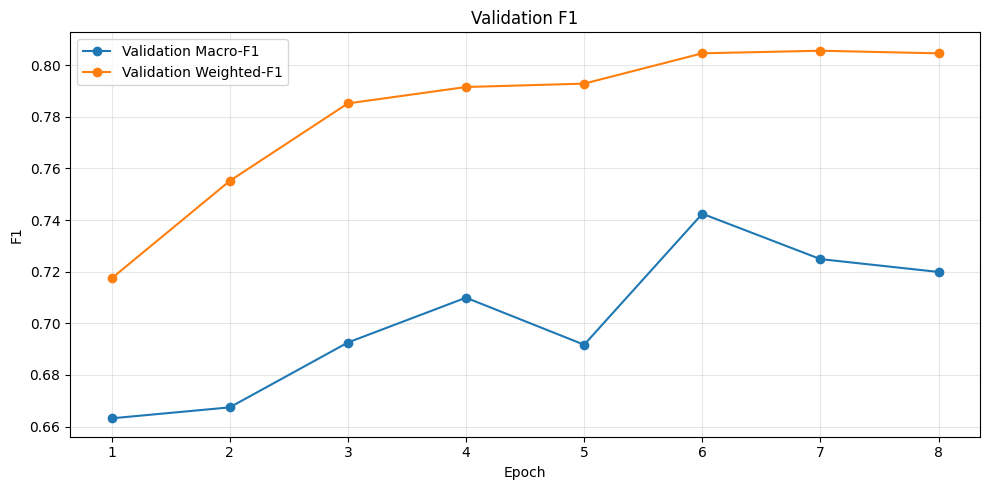

In [ ]:
def plot_training_history(history: pd.DataFrame):
    plt.figure(figsize=(10, 5))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(10, 5))

    plt.plot(
        history["epoch"],
        history["val_macro_f1"],
        marker="o",
        label="Validation Macro-F1"
    )

    plt.plot(
        history["epoch"],
        history["val_weighted_f1"],
        marker="o",
        label="Validation Weighted-F1"
    )

    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.title("Validation F1")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(
    history_rubert
)

#### Test Evaluation

In [ ]:
test_metrics, test_preds, test_labels = (evaluate_model(model_rubert, test_dataloader, criterion, device))

print("TEST RESULTS")

print(
    f"Test Loss: "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test Macro-F1: "
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    f"Test Weighted-F1: "
    f"{test_metrics['weighted_f1']:.4f}"
)

Evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

TEST RESULTS
Test Loss: 0.0223
Test Accuracy: 0.8429
Test Macro-F1: 0.7859
Test Weighted-F1: 0.8389


#### Classification report

In [ ]:
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

               precision    recall  f1-score   support

    Геометрия     0.8810    1.0000    0.9367        37
      Дирихле     0.6087    0.5185    0.5600        27
Комбинаторика     0.7887    0.6914    0.7368        81
    Многочлен     0.8235    0.7778    0.8000        36
 Теория чисел     0.8760    0.9163    0.8957       239

     accuracy                         0.8429       420
    macro avg     0.7956    0.7808    0.7859       420
 weighted avg     0.8379    0.8429    0.8389       420



### Сonfusion matrix

To understand class-level performance and inter-class confusion, we plot both raw counts and normalized confusion matrices

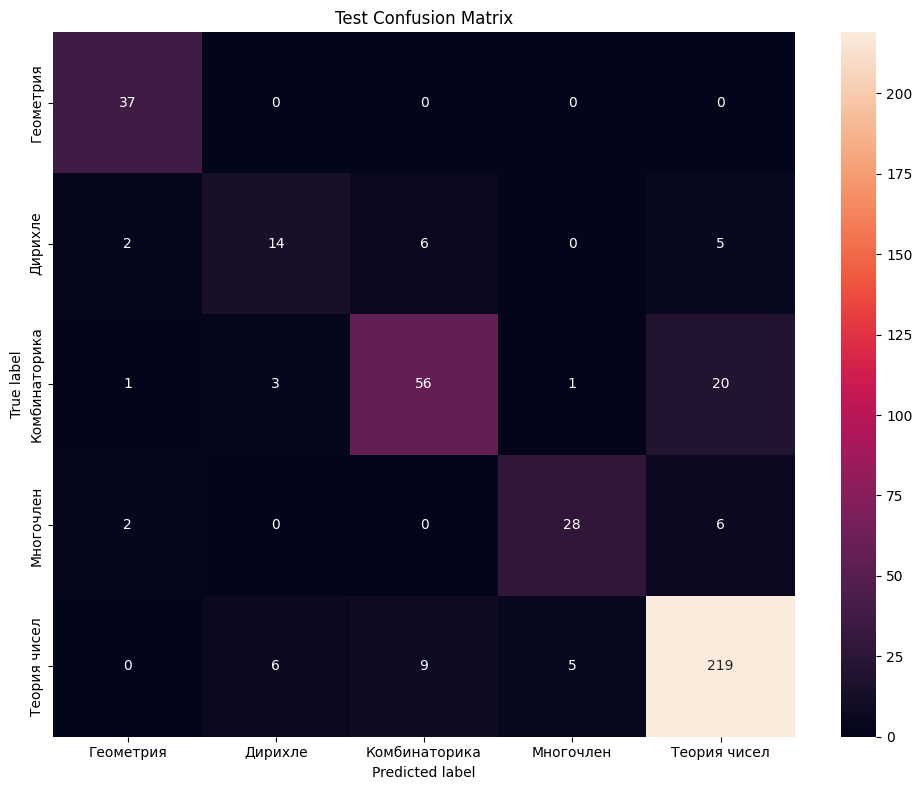

In [ ]:
cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

Normalized confusion matrix:

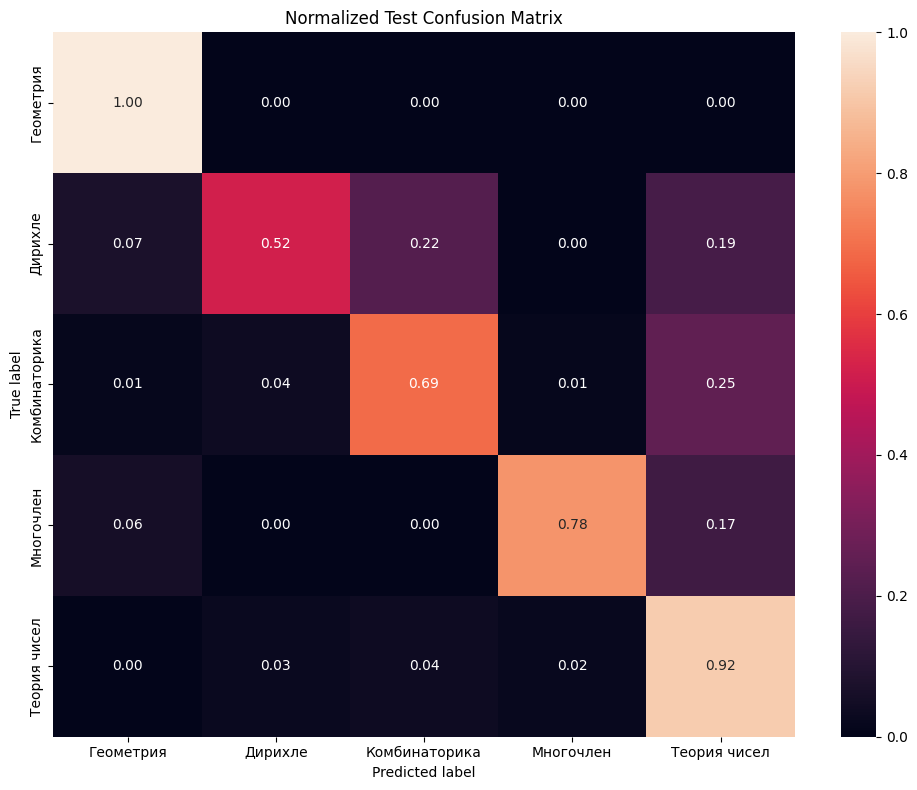

In [ ]:
cm_normalized = (
    cm.astype(float) /
    cm.sum(axis=1, keepdims=True)
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(
    "Normalized Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

Analysis of the raw and normalized confusion matrices reveals high classification accuracy on dominant and visually distinct subjects, alongside noticeable inter-class confusion driven by dataset imbalance and overlapping domain concepts.

Number Theory acts as a major false-positive sink across the matrix. It absorbed 25% of Combinatorics, 19% of Dirichlet, and 17% of Polynomials. This is directly tied to class imbalance, as the model defaults to the majority class when encountering ambiguous numeric phrasing.

The Dirichlet Principle is a proof technique frequently used within counting, set partitioning, and integer distribution tasks. Because Dirichlet problems inherently feature combinatoric setups or number-theoretic goals, the Transformer model struggles to isolate it as a distinct standalone topic.

Geometry remains almost completely decoupled from the algebraic categories, showing 0% confusion toward other classes and receiving only negligible false positives (7% from Dirichlet, 6% from Polynomials).

### Attention analysis

To inspect what features the Transformer model focuses on when making predictions

In [ ]:
def get_attention_outputs(
    model,
    tokenizer,
    text,
    device,
    max_length=256
):

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = (
        inputs["input_ids"]
        .to(device)
    )

    attention_mask = (
        inputs["attention_mask"]
        .to(device)
    )

    tokens = tokenizer.convert_ids_to_tokens(
        input_ids[0]
    )

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_attentions=True
        )

    return (
        tokens,
        attention_mask[0].detach().cpu(),
        outputs["attentions"]
    )

#### Plot attention matrix

This function averages and visualizes token-to-token attention weights across all heads for a specified Transformer layer, allowing us to inspect how subwords interact semantically and extract the attention matrix to quantify shifts between the untrained and fine-tuned model

In [ ]:
def plot_mean_attention_matrix(
    model,
    tokenizer,
    text,
    layer_id=11,
    device=device,
    max_length=256,
    figsize=(12, 10),
    fontsize=8
):
    tokens, attention_mask, attentions = get_attention_outputs(
        model=model,
        tokenizer=tokenizer,
        text=text,
        device=device,
        max_length=max_length
    )

    valid_length = int(attention_mask.sum().item())
    tokens = tokens[:valid_length]

    # attentions[layer_id][0] has dimensions (12_heads, seq_len, seq_len)
    # Averaging along the 0 axis (across all heads)
    mean_attn = attentions[layer_id][0].mean(dim=0)

    # Trim to the actual length of the sequence
    mean_attn = mean_attn[:valid_length, :valid_length].detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        mean_attn,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="Blues",
        annot=False,
        cbar=True,
        ax=ax
    )

    plt.title(f"Mean Attention Matrix | Layer {layer_id + 1}")
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")

    ax.set_xticklabels(tokens, rotation=90, ha="center", fontsize=fontsize)
    ax.set_yticklabels(tokens, rotation=0, ha="right", fontsize=fontsize)

    plt.tight_layout()
    plt.show()

    return mean_attn

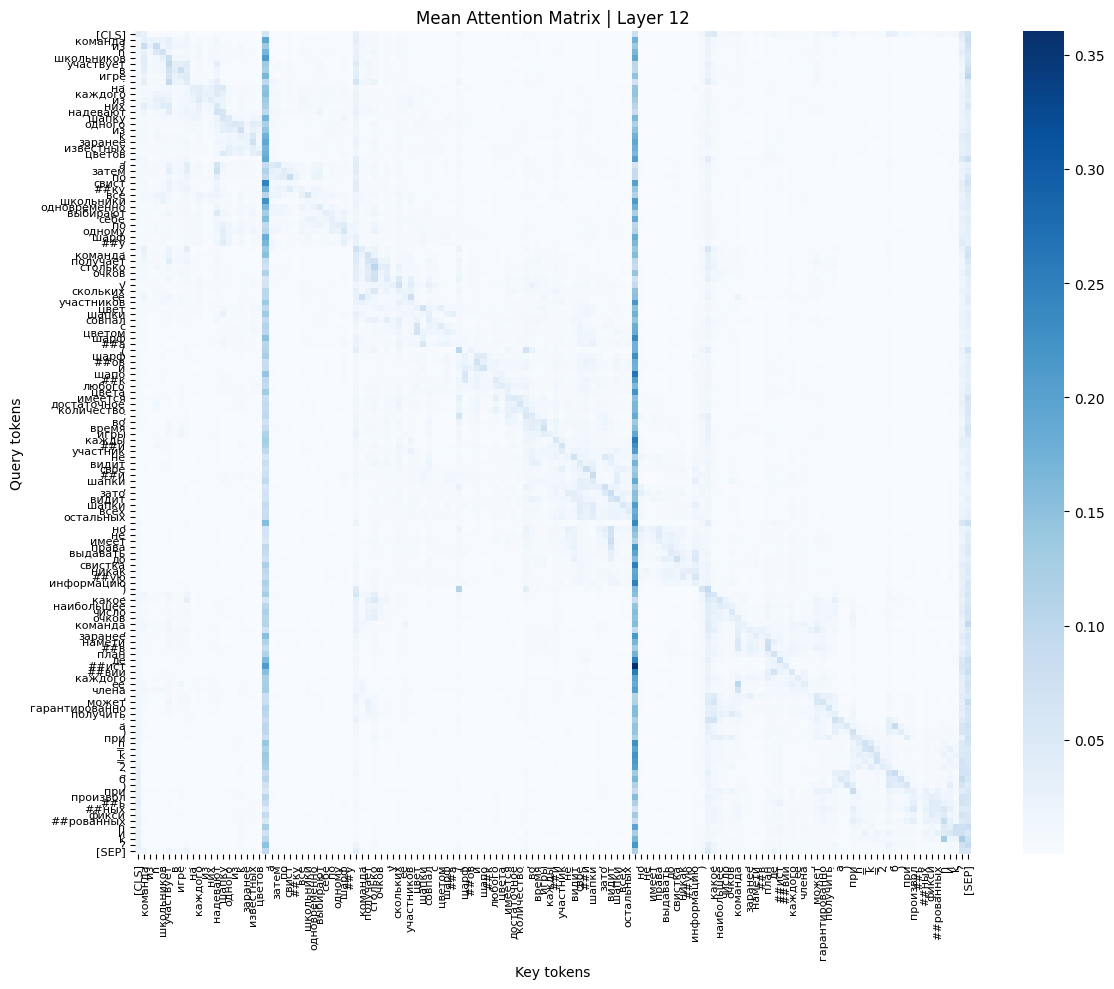

In [ ]:
sample_text = test_df["text"].iloc[0]

mean_untrained = plot_mean_attention_matrix(
    model=untrained_model,
    tokenizer=tokenizer_rubert,
    text=sample_text,
    layer_id=11,
    device=device
)

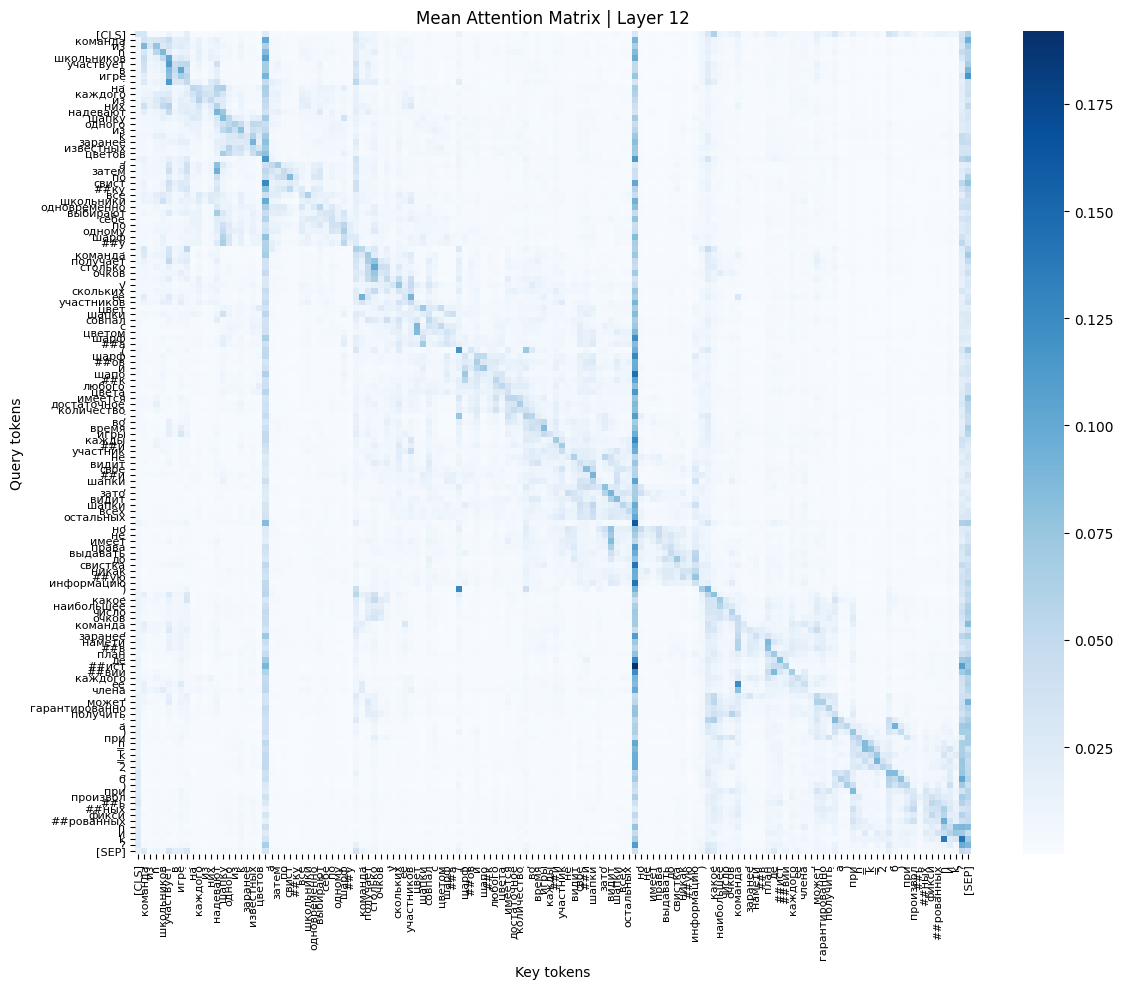

In [ ]:
mean_trained = plot_mean_attention_matrix(
    model=model_rubert,
    tokenizer=tokenizer_rubert,
    text=sample_text,
    layer_id=11,
    device=device
)

Comparing the Layer 12 mean attention matrices between the untrained baseline and the fine-tuned ruBert-large model reveals a structural shift from rigid, syntax-dominated attention to task-specific semantic context aggregation

Calculating the exact difference matrix:

In [ ]:
diff = abs(mean_untrained - mean_trained)

print(f"Maximum change of attention: {diff.max():.6f}")
print(f"Average change in attention across all tokens: {diff.mean():.6f}")

Maximum change of attention: 0.168282
Average change in attention across all tokens: 0.002413


Fine-tuning induced highly targeted focus shifts, achieving a maximum attention reallocation of **16.83%** on key domain tokens while maintaining global sequence stability with a minimal average change of just **0.24%** across all tokens

#### СLS attention function

We visualize attention distributions across sequence tokens for both correct and misclassified predictions

In [ ]:
def plot_mean_cls_attention(model, tokenizer, text, layer_id, device, max_length=256, fontsize=8):
    tokens, attention_mask, attentions = get_attention_outputs(
        model, tokenizer, text, device, max_length
    )
    valid_len = int(attention_mask.sum().item())
    tokens = tokens[:valid_len]

    # Averaging the attention [CLS] of a token over all heads of the selected layer
    mean_cls_attn = attentions[layer_id][0, :, 0, :valid_len].mean(dim=0).detach().cpu().numpy()

    plt.figure(figsize=(14, 3.5))

    ax = sns.heatmap(
        mean_cls_attn.reshape(1, -1),
        xticklabels=tokens,
        yticklabels=['Mean CLS'],
        cmap="Reds",
        cbar=True,
        cbar_kws={"shrink": 0.6, "pad": 0.02}
    )

    plt.title(f"Layer {layer_id + 1} | Mean CLS Attention across heads", pad=15)

    plt.xticks(rotation=90, ha="center", fontsize=fontsize)
    plt.yticks(rotation=0, fontsize=fontsize)

    plt.tight_layout()
    plt.show()

#### Interactive Attention Visualization

We construct an interactive graph of the distribution of attention across all layers and attention heads

In [ ]:
text_example = test_df["text"].iloc[0]

inputs = tokenizer_rubert(text_example, return_tensors="pt", truncation=True, max_length=128).to(device)

backbone = model_rubert.backbone

# Passing data directly through the backend with a request for attention
with torch.no_grad():
    outputs = backbone(**inputs, output_attentions=True)

# bertviz visualisation
tokens = tokenizer_rubert.convert_ids_to_tokens(inputs['input_ids'][0])
head_view(outputs.attentions, tokens)

Buffered data was truncated after reaching the output size limit.

### Error analysis

In [ ]:
test_analysis = test_df[
    ["text", "label", "label_id"]
].copy()

test_analysis["pred_id"] = (
    test_preds
)

test_analysis["pred_label"] = (
    label_encoder.inverse_transform(
        test_preds
    )
)

test_analysis["correct"] = (
    test_analysis["label_id"]
    ==
    test_analysis["pred_id"]
)

errors_df = test_analysis[
    ~test_analysis["correct"]
].copy()

print(
    "Number of test errors:",
    len(errors_df)
)

print(
    errors_df[
        [
            "label",
            "pred_label",
            "text"
        ]
    ].head(20).to_string()
)

Number of test errors: 66
             label     pred_label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

#### Attention of the correct example

TRUE: Комбинаторика
PRED: Комбинаторика

TEXT: Команда из n школьников участвует в игре : на каждого из них надевают шапку одного из k заранее известных цветов, а затем по свистку все школьники одновременно выбирают себе по одному шарфу. Команда получает столько очков, у скольких её участников цвет шапки совпал с цветом шарфа (шарфов и шапок любого цвета имеется достаточное количество; во время игры каждый участник не видит своей шапки, зато видит шапки всех остальных, но не имеет права выдавать до свистка никакую информацию). Какое наибольшее число очков команда, заранее наметив план действий каждого её члена, может гарантированно получить : а) при n = k = 2; б) при произвольных фиксированных n и k?


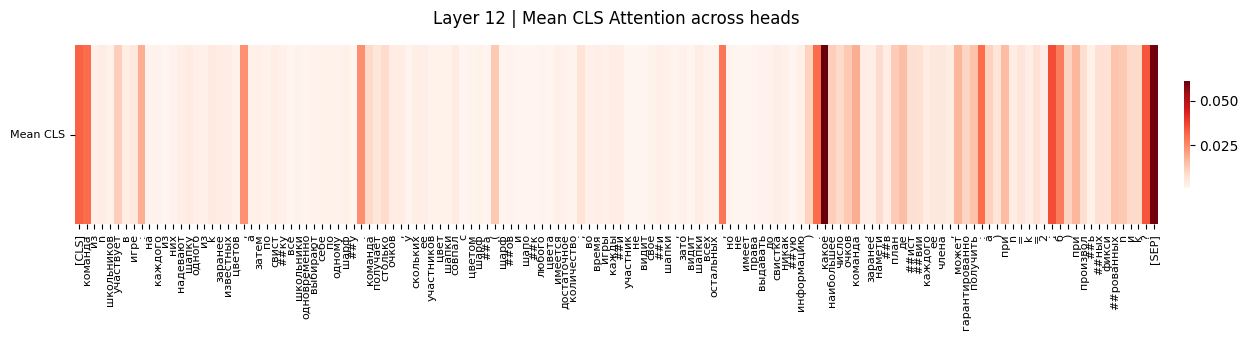

In [ ]:
correct_examples = test_analysis[
    test_analysis["correct"]
]

correct_text = (
    correct_examples.iloc[0]["text"]
)

print(
    "TRUE:",
    correct_examples.iloc[0]["label"]
)

print(
    "PRED:",
    correct_examples.iloc[0]["pred_label"]
)

print(
    "\nTEXT:",
    correct_text
)

plot_mean_cls_attention(
    model=model_rubert,
    tokenizer=tokenizer_rubert,
    text=correct_text,
    layer_id=11,
    device=device
)

The Layer 12 `[CLS]` token successfully identifies the mathematical domain by heavily attending to the core question formulation (such as *“какое”*) and critical algebraic constraints (*“n”*, *“k”*, *“=”*)

#### Attention of the incorrect example

TRUE: Теория чисел
PRED: Комбинаторика

TEXT: В стране Анчурии, где правит президент Мирафлорес, приблизилось время новых президентских выборов. В стране ровно 20 миллионов избирателей, из которых только один процент поддерживает Мирафлореса (регулярная армия Анчурии). Мирафлорес, естественно, хочет быть избранным, но, с другой стороны, он хочет, чтобы выборы были "демократическими". "Демократическим голосованием" Мирафлорес называет вот что : все избиратели разбиваются на равные группы; каждая из этих групп вновь разбивается на некоторое количество равных групп, причём большие группы могут разбиваться на разное количество меньших групп, затем эти группы снова разбиваются и т.д. В самых мелких группах выбирают представителя группы "выборщика" для голосования в большей группе : выборщики в этой большей группе выбирают выборщика для голосования в ещё большей группе и т.д. Наконец, представители самых больших групп выбирают президента. Мирафлорес делит избирателей на группы по своей воле 

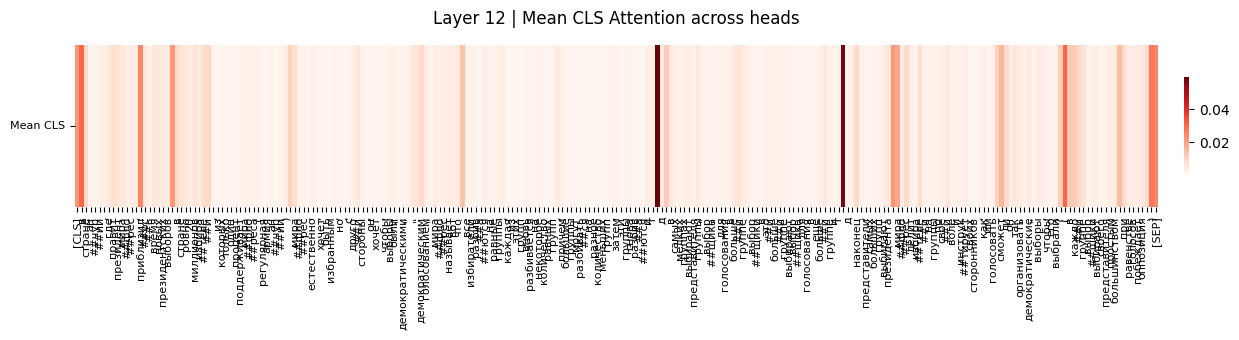

In [ ]:
wrong_text = errors_df.iloc[0]["text"]

print(
    "TRUE:",
    errors_df.iloc[0]["label"]
)

print(
    "PRED:",
    errors_df.iloc[0]["pred_label"]
)

print(
    "\nTEXT:",
    wrong_text
)

plot_mean_cls_attention(
    model=model_rubert,
    tokenizer=tokenizer_rubert,
    text=wrong_text,
    layer_id=11,
    device=device
)

The Layer 12 `[CLS]` token gets distracted by the dense narrative storytelling context (such as *"президент"*, *"выборы"*, and *"страна"*) while exhibiting disproportionate attention spikes on isolated, non-semantic characters like *"д"*. Because the model disperses its focus across background narrative vocabulary rather than isolating the underlying mathematical mechanics and structural constraints, it fails to identify the correct domain topic

### Conclusion

The fine-tuned ruBert-large model achieved high performance on the task. The high Weighted F1 score relative to Macro F1 highlights strong overall accuracy, while the Macro F1 reflects variance across dominant and minority classes.

Dirichlet Principle (F1: 0.5600 | Recall: 0.5185) faced the highest error rate. The Dirichlet principle is a general proof method rather than a standalone domain topic; problems involving Dirichlet often feature combinatorics, leading to high semantic confusion with majority classes.

Freezing the first 8 layers preserved generic language representations while reducing trainable parameters from 426.9M to 202.6M (~47.46% trainable). This accelerated training and prevented overfitting on minority classes.

Mean pooling provided a robust sequence representation over max/CLS pooling alone. Using FocalLoss mitigated extreme imbalance effects, ensuring reasonable recall on minority classes like Dirichlet and Polynomials.

Fine-tuning shifted attention from generic syntactic tokens to domain-specific context anchors.

Misclassified samples (such as long story-based problem statements) showed dispersed [CLS] attention across narrative context rather than focusing on underlying mathematical operations.